### 1. Importing Libraries and Datasets

In [1]:
# Operationals libraries
import pandas as pd
import numpy as np

# Plot libraries/visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical modeling and diagnostics
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# We import the three datasets that will be used in this work: the training dataset, the test dataset, and the submission dataset.
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_submission_df = pd.read_csv("sample_submission.csv")

### 2. Understanding the Dataset

In [3]:
train_df.head(n=5)

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [4]:
list(train_df.columns)

['id',
 'age',
 'gender',
 'course',
 'study_hours',
 'class_attendance',
 'internet_access',
 'sleep_hours',
 'sleep_quality',
 'study_method',
 'facility_rating',
 'exam_difficulty',
 'exam_score']

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [6]:
train_df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


<Axes: xlabel='exam_score', ylabel='Count'>

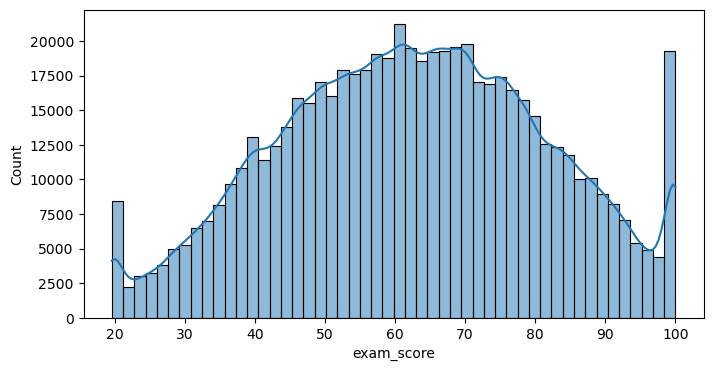

In [7]:
plt.figure(figsize=(8,4))
sns.histplot(train_df["exam_score"], bins=50, kde=True)

### 3. Preparing the Dataset for Statistical Modeling

In [8]:
# Criando um database menor para trabalhar com menos pode computacional

small_train_df = train_df.sample(frac=0.01, random_state=42)
small_train_df.shape

(6300, 13)

#### 3.1. The transformations below may or may not be used in the final model

In [9]:
# Transformações em study_hours
small_train_df["study_hours_log"] = np.log(small_train_df["study_hours"] + 1)
small_train_df["study_hours_sq"] = small_train_df["study_hours"] ** 2

# Transformações em class_attendance
small_train_df["class_attendance_log"] = np.log(small_train_df["class_attendance"] + 1)
small_train_df["class_attendance_sq"] = small_train_df["class_attendance"] ** 2

# Transformações em sleep_hours
small_train_df["sleep_hours_log"] = np.log(small_train_df["sleep_hours"] + 1)
small_train_df["sleep_hours_sq"] = small_train_df["sleep_hours"] ** 2

### 4. Ordinary Least Squares (OLS) 

In [10]:
# Define the OLS formula.

ols_formula = """
exam_score ~
    study_hours
  + study_hours_log
  + study_hours_sq
  + class_attendance
  + sleep_hours
  + C(sleep_quality)
  + C(study_method)
  + C(facility_rating)
"""

# Create an OLS model.

OLS = ols(formula = ols_formula, data = small_train_df)

# Fit the model.
model = OLS.fit()

# Save the results summary.

model_results = model.summary()

# Display the model results.

model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             exam_score   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     1742.
Date:                Sun, 01 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:39:09   Log-Likelihood:                -22598.
No. Observations:                6300   AIC:                         4.522e+04
Df Residuals:                    6286   BIC:                         4.532e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           19.1646      0.888     21.590      0.000      17.424      20.905
C(sleep_quality)[T.good]             3.7413      0.272     13.765      0.000       3.209       4.274
C(sleep_quality)[T.poor]            -4.8198      0.272    -17.722      0.000      -5.353      -4.287
C(study_method)[T.group study]      -7.0775      0.350    -20.211      0.000      -7.764      -6.391
C(study_method)[T.mixed]            -4.5688      0.345    -13.234      0.000      -5.246      -3.892
C(study_method)[T.online videos]    -8.0548      0.351    -22.949      0.000      -8.743      -7.367
C(study_method)[T.self-study]       -8.9736      0.340    -26.413      0.000      -9.640      -8.308
C(facility_rating)[T.low]           -7.1950      0.273    -26.351      0.000      -7.730      -6.660
C(facility_rating)[T.medium]        -3.9946      0.272    -14.668      0.000      -4.528      -3.461
study_hours                          9.1432      1.024      8.927      0.000       7.135      11.151
study_hours_log                     -7.5237      2.136     -3.523      0.000     -11.710      -3.337
study_hours_sq                      -0.2001      0.066     -3.026      0.002      -0.330      -0.070
class_attendance                     0.3126      0.006     49.070      0.000       0.300       0.325
sleep_hours                          1.3277      0.063     21.019      0.000       1.204       1.451
==============================================================================
Omnibus:                        0.401   Durbin-Watson:                   1.980
Prob(Omnibus):                  0.818   Jarque-Bera (JB):                0.358
Skew:                           0.007   Prob(JB):                        0.836
Kurtosis:                       3.034   Cond. No.                     1.69e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.69e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### 4.1. Graphical Analysis of Numerical Variables

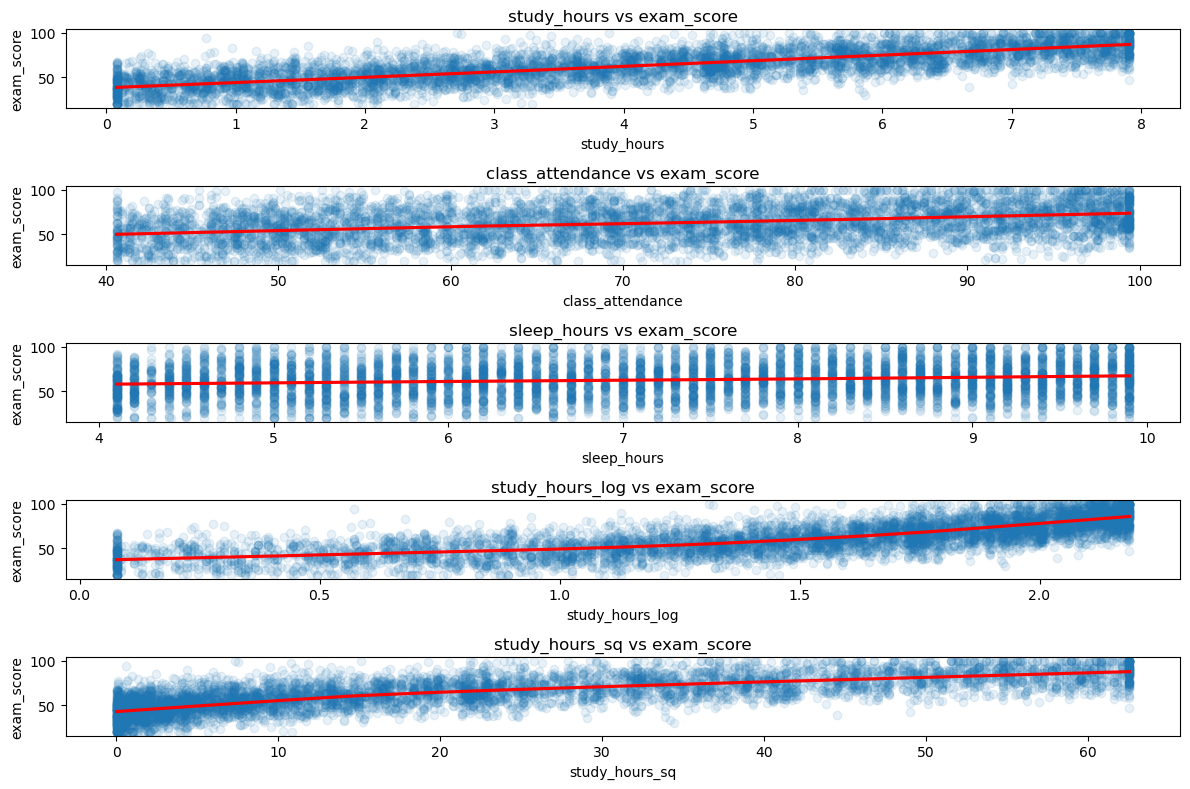

In [11]:
# Variables to be analyzed in the plot
num_vars = [
    "study_hours",
    "class_attendance",
    "sleep_hours",
    "study_hours_log",
    "study_hours_sq"
    
]

# Creating the plots
fig, axes = plt.subplots(5, 1, figsize=(12, 8))
axes = axes.flatten()

# A loop to generate one plot for each variable
for i, var in enumerate(num_vars):
    sns.regplot(
        x=var,
        y="exam_score",
        data=small_train_df,
        scatter_kws={"alpha": 0.1},
        line_kws={"color": "red"},
        lowess=True,
        ax=axes[i]
    )
    axes[i].set_title(f"{var} vs exam_score")

# Display the plots in an adjusted layout
plt.tight_layout()
plt.show()

#### 4.2. Graphical Analysis of Categorical Variables

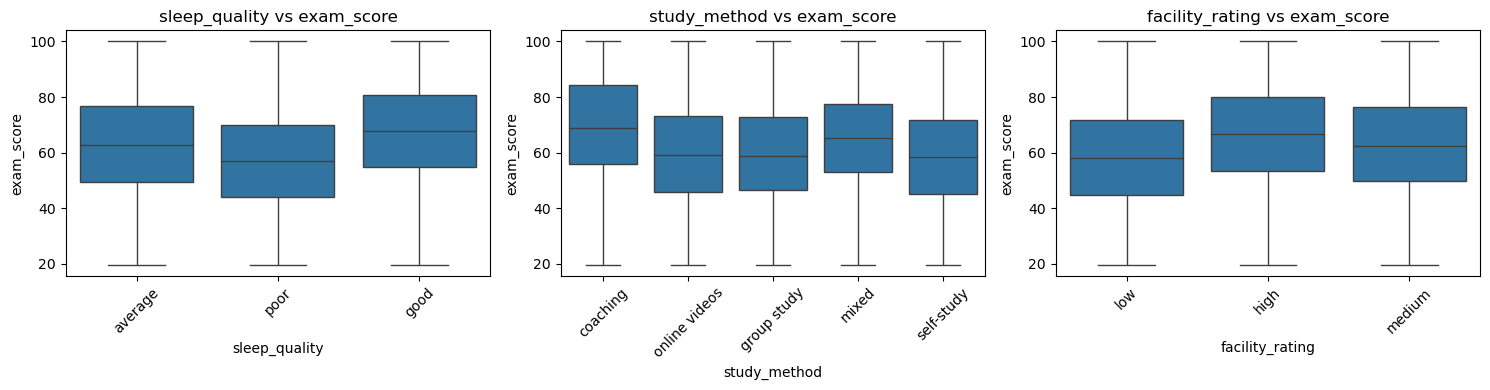

In [12]:
cat_vars = [
    "sleep_quality",
    "study_method",
    "facility_rating"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, var in enumerate(cat_vars):
    sns.boxplot(
        x=var,
        y="exam_score",
        data=small_train_df,
        ax=axes[i]
    )
    axes[i].set_title(f"{var} vs exam_score")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show();

#### 4.3. Model Residual Analysis

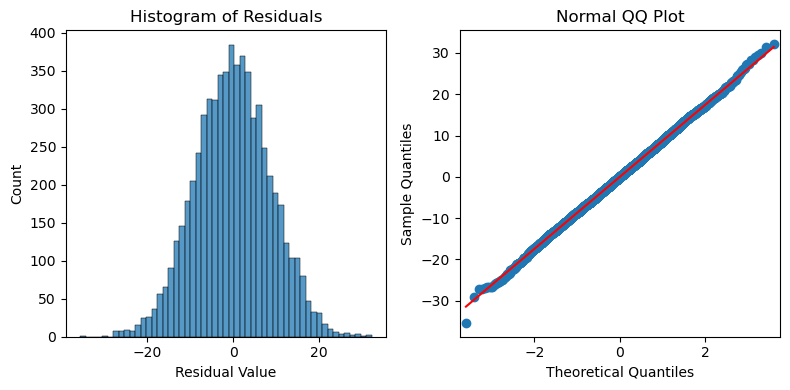

In [13]:
# 1) Calcular resíduos (modelo OLS do statsmodels)
residuals = model.resid  # model = sm.OLS.from_formula(...).fit()

# 2) Figura 1x2
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# 3) Histograma dos resíduos
sns.histplot(residuals, ax=axes[0])
axes[0].set_xlabel("Residual Value")
axes[0].set_title("Histogram of Residuals")

# 4) Q-Q plot dos resíduos
sm.qqplot(residuals, line="s", ax=axes[1])
axes[1].set_title("Normal QQ Plot")

plt.tight_layout()
plt.show()

#### 4.4. Graphical Analysis of Multicollinearity

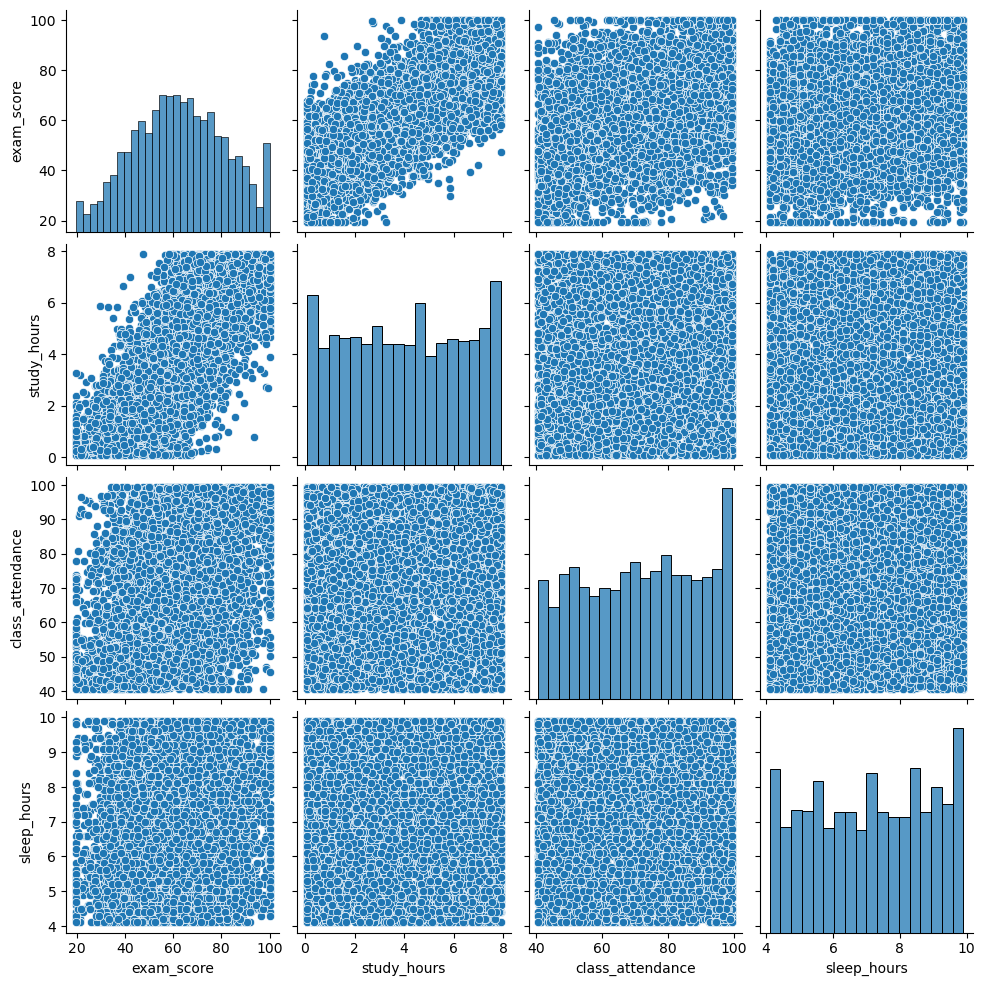

In [14]:
# VAmos verificar multicolinearidade

vars_model = [
    "exam_score",
    "study_hours",
    "class_attendance",
    "sleep_hours"
]

sns.pairplot(
    small_train_df[vars_model]
)

#### 4.5. Verificando se há multicolinearidade entre as variáveis numéricas

In [15]:
# Selecionar apenas variáveis numéricas do modelo
X_vif = small_train_df[
    ["study_hours", "class_attendance", "sleep_hours"]
]

# Adicionar constante
X_vif = sm.add_constant(X_vif)

# Calcular VIF
vif_df = pd.DataFrame()
vif_df["variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df

,variable,VIF
0,const,35.789184
1,study_hours,1.005352
2,class_attendance,1.005311
3,sleep_hours,1.000640


### 5. Running the Model on the Test Dataset

In [16]:
test_df["study_hours_log"] = np.log(test_df["study_hours"] + 1)
test_df["study_hours_sq"] = test_df["study_hours"] ** 2

In [17]:
test_df_model = test_df[
    [
        "study_hours",
        "study_hours_log",
        "study_hours_sq",
        "class_attendance",
        "sleep_hours",
        "sleep_quality",
        "study_method",
        "facility_rating"
    ]
]

In [18]:
test_df["exam_score"] = model.predict(test_df_model)

In [19]:
test_df[["exam_score"]].head(3)

,exam_score
0,72.296592
1,69.992476
2,87.232305


In [20]:
submission_df = test_df[["id", "exam_score"]]

submission_df.to_csv(
    "submission_linear_model.csv",
    index=False
)